- graph()
- state
- edges
- nodes
- invoke
- stategraph()

In [6]:
def function1(input1):
    return input1 + " from first function"

def function2(input2):
    return input2 + " savita from second function"

def function3(input3):
    pass

print(function1("sunny"))
print(function2("savita"))

sunny from first function
savita savita from second function


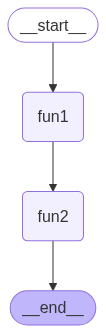

'hi this is sunny from first function savita from second function'

In [ ]:
from langgraph.graph import Graph
from IPython.display import Image, display


workflow1=Graph()

workflow1.add_node("fun1",function1)
workflow1.add_node("fun2",function2)
workflow1.add_edge("fun1","fun2")
workflow1.set_entry_point("fun1")
workflow1.set_finish_point("fun2")

app=workflow1.compile()
display(Image(app.get_graph().draw_mermaid_png()))
app.invoke("hi this is sunny")

In [12]:
for output in app.stream("hi this is rohit"):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")

here is output from fun1
_______
hi this is rohit from first function


here is output from fun2
_______
hi this is rohit from first function savita from second function




In [15]:
from langchain_google_genai import ChatGoogleGenerativeAI

def llm(input):
    model=ChatGoogleGenerativeAI(model='gemini-1.5-flash')
    output=model.invoke(input)
    return output.content

def token_counter(input):
    token=input.split()
    token_number=len(token)
    return f"total token number in the generated answer is {token_number}"

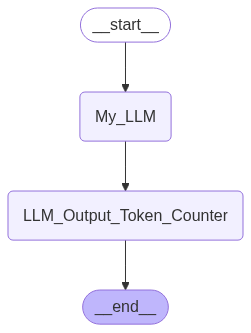

In [16]:
workflow2=Graph()
workflow2.add_node("My_LLM",llm)
workflow2.add_node("LLM_Output_Token_Counter",token_counter)
workflow2.add_edge("My_LLM","LLM_Output_Token_Counter")
workflow2.set_entry_point("My_LLM")
workflow2.set_finish_point("LLM_Output_Token_Counter")
app=workflow2.compile()
display(Image(app.get_graph().draw_mermaid_png()))

In [17]:
app.invoke("can you tell me about the india's capital?")

'total token number in the generated answer is 131'

In [18]:
app.invoke("tell me about the tata enterpirse in very detail.")

'total token number in the generated answer is 707'

In [19]:

for output in app.stream("tell me about the tata enterpirse in very detail."):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")

here is output from My_LLM
_______
Tata Enterprises is not a single entity but rather a vast and complex conglomerate, officially known as the Tata Group.  It's a multinational conglomerate headquartered in Mumbai, India, comprising numerous subsidiary companies operating across diverse sectors.  To understand it in detail, we need to break it down:

**I. History and Structure:**

* **Origins:** The group's history traces back to 1868 when Jamsetji Tata founded the Tata & Sons trading company.  His vision was to build businesses that served India's needs and contributed to its growth.
* **Structure:** The Tata Group isn't a typical hierarchical corporation.  It's a complex network of independent companies, many of which are publicly listed, held together by a shared philosophy and a common holding company, Tata Sons. Tata Sons owns a significant stake in several key Tata companies and plays a crucial role in strategic direction and governance.  However, the individual companies enjoy c

In [17]:
from langgraph.graph import Graph

def first_node(input):
    print(input, "First Node")
    
def second_node(input):
    print(input, "Second Node")

workflow = Graph()

workflow.add_node("First Node", first_node)
workflow.add_node("Second Node", second_node)
workflow.add_edge("First Node", "Second Node")
workflow.set_entry_point("First Node")
workflow.set_finish_point("Second Node")
app = workflow.compile()
app.invoke("Hello")

Hello First Node
None Second Node
